In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

# Data Cleaning

To ensure reliable analysis, several data cleaning steps were performed on the dataset.

---

## 1. Handling Missing Values

- Columns with 100% missing values were removed.
- Other missing values were retained to preserve important information, especially in weather-related features.

---

## 2. Date and Time Processing

- `Start_Time` was converted to datetime format.
- A new feature `Hour` was extracted to analyze accident patterns over time.

---

## 3. Unit Conversions

To improve interpretability, several unit conversions were applied:

- Temperature: Fahrenheit → Celsius
- Distance: miles → kilometers
- Visibility: miles → kilometers
- Wind Speed: mph → km/h

---

## 4. Data Type Correction

- Ensured proper data types for categorical and boolean variables.
- Converted time-related features for temporal analysis.

---

## 5. Duplicate and Data Quality Check

- Duplicates were identified and removed where necessary.
- Data consistency was verified across key columns.

---

## Final Clean Dataset

After cleaning, the dataset is ready for exploratory data analysis with:

- Improved readability
- Consistent formats
- Reduced noise in critical features

In [46]:
df = pd.read_csv("../data/raw/US_Accidents_March23.csv", nrows=100000)

In [47]:
df.shape

(100000, 46)

In [48]:
df= df.drop_duplicates()

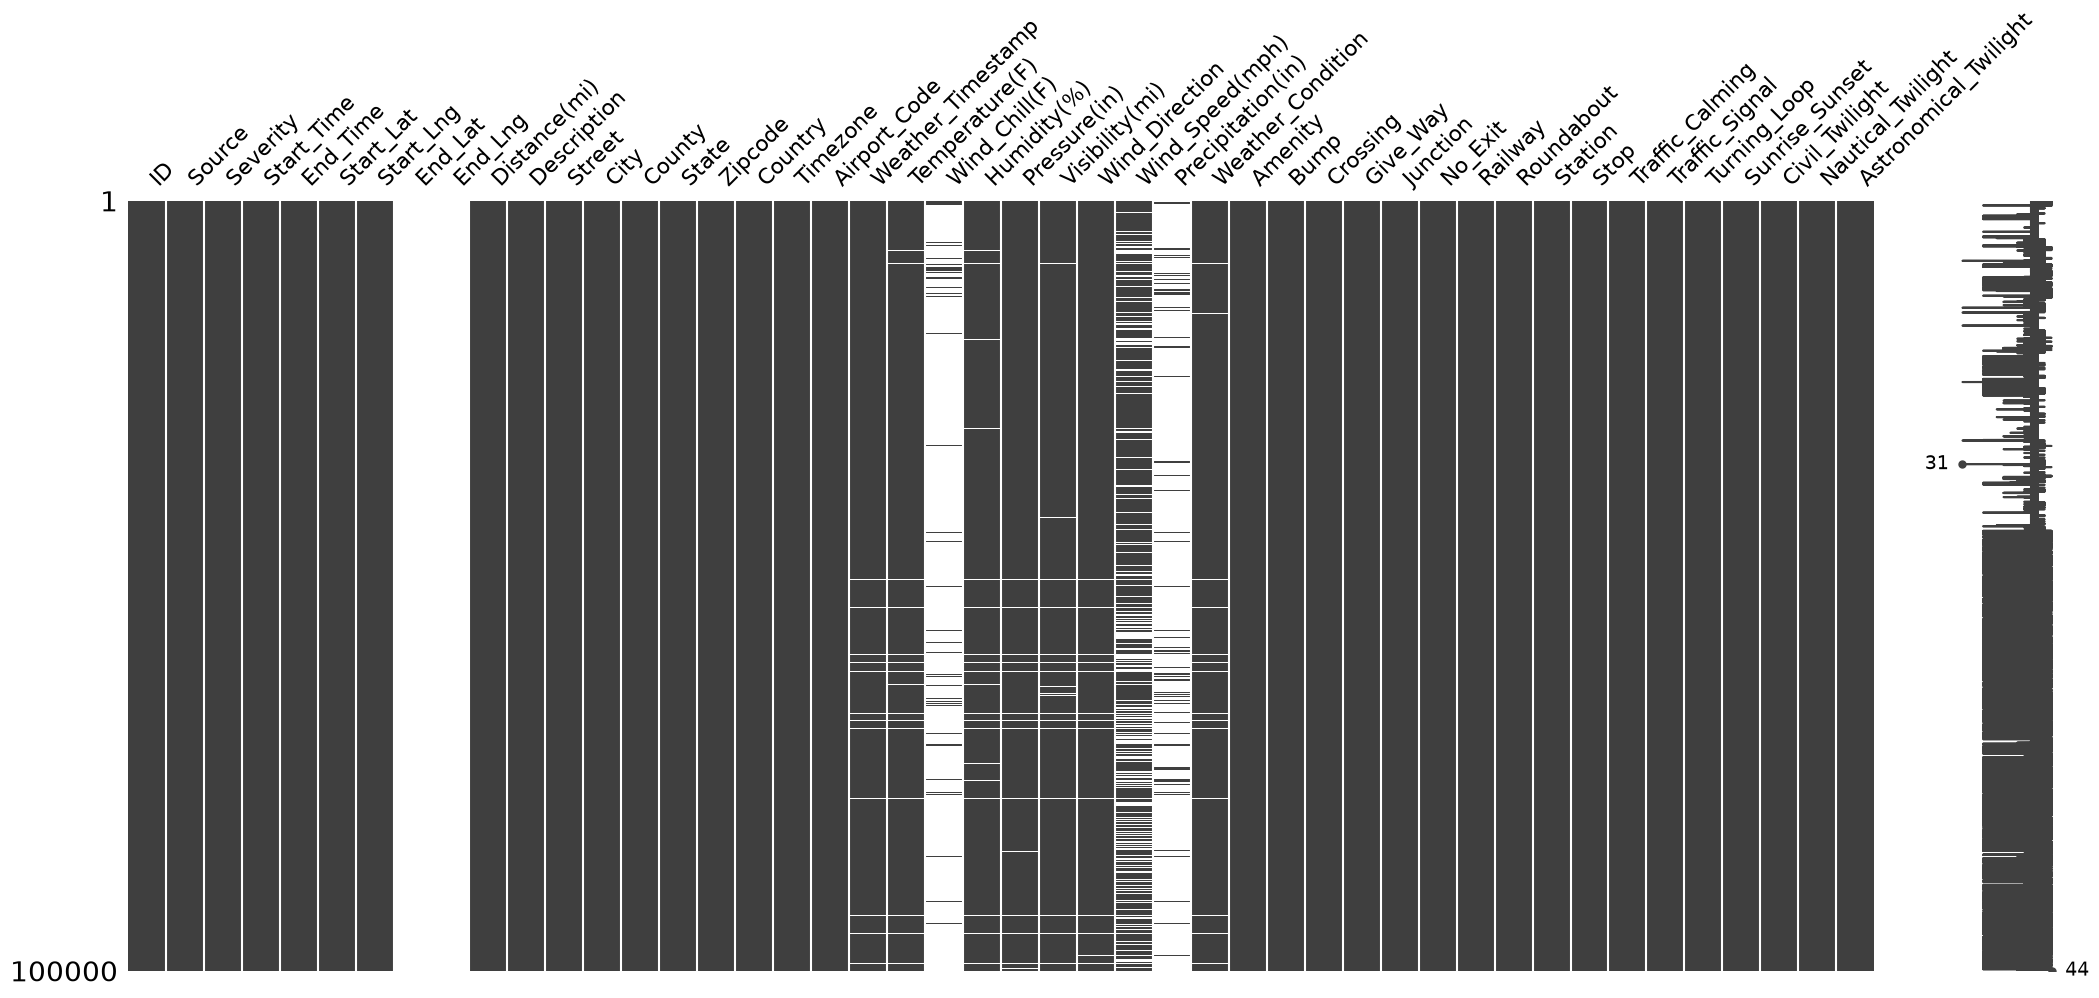

In [49]:
msno.matrix(df)
plt.show()

In [50]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round((df.isnull().sum()/len(df))*100,2)
})

missing[missing['Missing Values'] > 0].sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
End_Lat,100000,100.00
End_Lng,100000,100.00
Wind_Chill(F),95678,95.68
Precipitation(in),92632,92.63
Wind_Speed(mph),23820,23.82
Humidity(%),1856,1.86
Visibility(mi),1846,1.85
Weather_Condition,1604,1.60
Temperature(F),1591,1.59
Pressure(in),1292,1.29


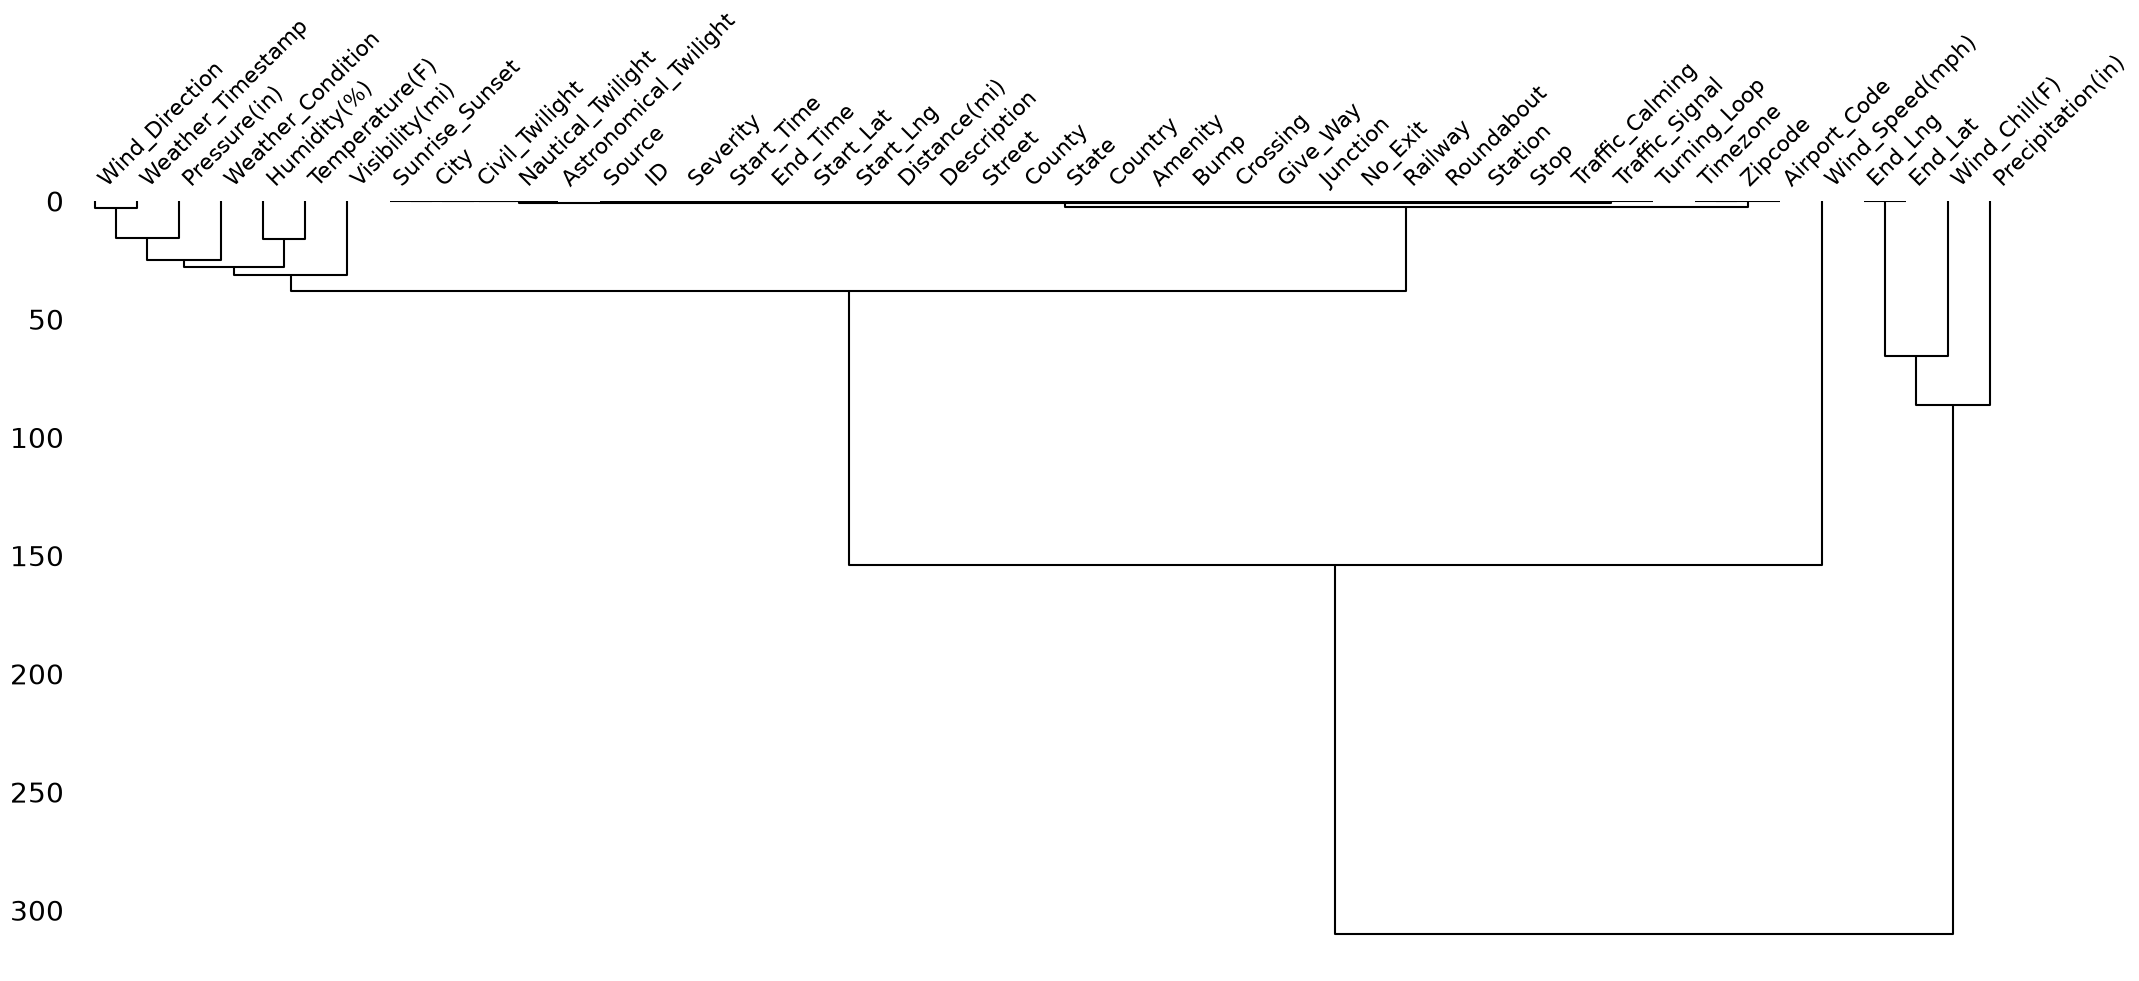

In [51]:
msno.dendrogram(df)
plt.show()

In [52]:
df.columns[df.isnull().all()]

Index(['End_Lat', 'End_Lng'], dtype='str')

In [53]:
df.drop(columns=['End_Lat', 'End_Lng'], inplace=True)
df.shape

(100000, 44)

In [54]:
# Suppression des colonnes entièrement vides
df.dropna(axis=1, how='all', inplace=True)

# Conversion des unités
df['Temperature_C'] = ((df['Temperature(F)'] - 32) * 5/9).round(2)
df['Distance_km'] = (df['Distance(mi)'] * 1.60934).round(2)
df['Visibility_km'] = (df['Visibility(mi)'] * 1.60934).round(2)
df['Wind_Speed_kmh'] = (df['Wind_Speed(mph)'] * 1.60934).round(2)

# Conversion des dates
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['End_Time'] = pd.to_datetime(df['End_Time'])

# Vérification
df[['Temperature_C',
    'Distance_km',
    'Visibility_km',
    'Wind_Speed_kmh',
    'Start_Time']].head()

,Temperature_C,Distance_km,Visibility_km,Wind_Speed_kmh,Start_Time
0,2.72,0.02,16.09,NaN,2016-02-08 05:46:00
1,3.28,0.02,16.09,NaN,2016-02-08 06:07:59
2,2.22,0.02,16.09,5.63,2016-02-08 06:49:27
3,1.72,0.02,14.48,7.40,2016-02-08 07:23:34
4,2.22,0.02,9.66,5.63,2016-02-08 07:39:07


In [55]:
df['Duration_Hours'] = (
    df['End_Time'] - df['Start_Time']
).dt.total_seconds() / 3600
df['End_Time'] = pd.to_datetime(df['End_Time'])
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Hour'] = df['Start_Time'].dt.hour

In [56]:
df.to_csv(
    '../data/processed/us_accidents_clean.csv',
    index=False
)